# Book-ended multi-energy fit on real ZnPc XRR

Port of refl-analysis's `fit_orientation_graded.ipynb`. Fits the book-ended ZnPc orientation/density profile against real XRR data at all 21 energies in the legacy DFT-fit extraction (carbon K-edge, 250-289 eV), using refloxide's native `BookendedComponent` / `Objective` directly.

Companions: `real_data_repl.py` (discrete slabs, same dataset) and `bookended_multi_energy_repl.py` (same mechanics, synthetic data).

**Workflow**

1. Rebuild the DFT three-slab template at the 283.7 eV anchor, collapse surface/bulk/interface into one deferred-energy `BookendedComponent`.
2. Load real s+p data at all 21 energies; seed per-energy instrument corrections (label-swapped theta offsets; shared `energy_offset`).
3. Staged `differential_evolution` fits (geometry + densities, then tilt opening, then polish), with overlays at representative energies.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
import os
import pickle
from pathlib import Path

os.environ["POLARS_VERBOSE"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from refnx.analysis import CurveFitter, Transform

from refloxide.data import OpticalConstants, ReflectDataset
from refloxide.model import BookendedComponent, MaterialSLD, ReflectModel, UniTensorSLD
from refloxide.objective import Objective, thread_workers
from refloxide.pxr.energy.bookended import bookended_from_three_slabs
from refloxide.pxr.energy.ooc import OocAnchor


## Paths and DFT-fit extraction

Sibling `refl-analysis` checkout; same one-time extraction that `dft_model_comparison_repl.py` uses (`dft_en_offset_new2_summary.json` / `_data.parquet`).


In [2]:
DFT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/dft"
SUMMARY_PATH = DFT_DIR / "dft_en_offset_new2_summary.json"
DATA_PATH = DFT_DIR / "dft_en_offset_new2_data.parquet"
for path in (SUMMARY_PATH, DATA_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"missing {path} -- run the one-time extraction (in the "
            "refl-analysis venv, which has pyref) against "
            f"{DFT_DIR / 'dft_en_offset_new2.pkl'} first, or see "
            "dft_model_comparison_repl.py for the extraction story"
        )

summary = json.loads(SUMMARY_PATH.read_text())
ANCHOR_ENERGY = float(summary["anchor_energy"])
NUM_SLABS_FIT = 24
NUM_SLABS_PLOT = 100
SHOW_ENERGIES = (250.0, 283.7, 285.1)
print(
    f"anchor energy: {ANCHOR_ENERGY} eV, "
    f"layers: {[layer['name'] for layer in summary['layers']]}"
)


anchor energy: 283.7 eV, layers: ['Vacuum', 'Surface', 'ZnPc', 'Contamination', 'Oxide', 'Substrate']


## Rebuild the DFT-fit template at the anchor energy

Two optical-constant wrappers share the same CSV: `OpticalConstants` for discrete `UniTensorSLD` slabs, and `OocAnchor` for the book-ended profile's Rust-side linear interpolator.


In [3]:
znpc_oc = OpticalConstants.from_file(summary["ooc_csv"])
znpc_anchor = OocAnchor.from_file(summary["ooc_csv"])


def build_template_structure():
    slabs = []
    for layer in summary["layers"]:
        if layer["kind"] == "uniaxial":
            sld = UniTensorSLD(
                znpc_oc,
                density=layer["density"],
                rotation=layer["rotation"],
                name=layer["name"],
            )
        else:
            sld = MaterialSLD(
                layer["formula"], density=layer["density"], name=layer["name"]
            )
        slabs.append(sld(layer["thick"], layer["rough"]))
    structure = slabs[0]
    for slab in slabs[1:]:
        structure = structure | slab
    return structure


template_structure = build_template_structure()
surface_slab = template_structure.slab("Surface")
bulk_slab = template_structure.slab("ZnPc")
interface_slab = template_structure.slab("Contamination")
oxide_layer = next(layer for layer in summary["layers"] if layer["name"] == "Oxide")
substrate_layer = next(
    layer for layer in summary["layers"] if layer["name"] == "Substrate"
)


## Collapse surface / bulk / interface into one deferred-energy book-ended profile

`energy=None` keeps `total_thick` / `tau_*` / `alpha_*` / `density_*` shared across every energy `ReflectModel` evaluates; only the OOC lookup changes per energy.


In [4]:
profile_fit = bookended_from_three_slabs(
    surface_slab,
    bulk_slab,
    interface_slab,
    znpc_anchor,
    energy=None,
    num_slabs=NUM_SLABS_FIT,
    mesh_constant=0.1,
    name="ZnPc",
)
profile_plot = bookended_from_three_slabs(
    surface_slab,
    bulk_slab,
    interface_slab,
    znpc_anchor,
    energy=ANCHOR_ENERGY,
    num_slabs=NUM_SLABS_PLOT,
    mesh_constant=0.1,
    name="ZnPc",
)
print(
    f"book-ended profile: total_thick={profile_fit.total_thick.value:.2f} A, "
    f"alpha_bulk={profile_fit.alpha_bulk.value:.3f} rad"
)


def build_structure(profile):
    vacuum = MaterialSLD("", 0, name="vacuum")(0, 0)
    oxide = MaterialSLD("SiO2", density=oxide_layer["density"], name="oxide")(
        oxide_layer["thick"], oxide_layer["rough"]
    )
    substrate = MaterialSLD("Si", density=substrate_layer["density"], name="substrate")(
        substrate_layer["thick"], substrate_layer["rough"]
    )
    return vacuum | BookendedComponent(profile) | oxide | substrate


structure_fit = build_structure(profile_fit)
structure_plot = build_structure(profile_plot)


book-ended profile: total_thick=199.59 A, alpha_bulk=1.214 rad


## Graded book-ended profile vs DFT three-slab template

Orientation/density vs depth is energy-independent for a book-ended profile (only the OOC changes with photon energy).


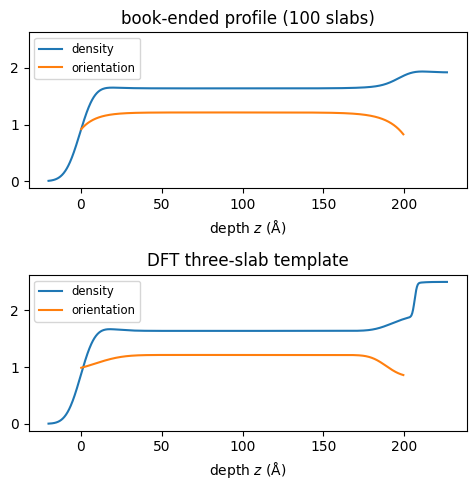

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharey=True)
structure_plot.plot.param("density|orientation", ax=axes[0], roughness=True)
axes[0].set_title(f"book-ended profile ({NUM_SLABS_PLOT} slabs)")
template_structure.plot.param("density|orientation", ax=axes[1], roughness=True)
axes[1].set_title("DFT three-slab template")
fig.tight_layout()
plt.show()


## Load real s+p data and build the multi-energy model

Freeze the entire structure first (`Scatterer.__call__` sets slab `thick`/`rough` to `vary=True` by default, including vacuum/oxide/substrate). Oxide and substrate stay fixed at the DFT template values throughout.


In [6]:
frame = pl.read_parquet(DATA_PATH)
dataset = ReflectDataset.from_polars(frame)
energies = sorted(frame["energy"].unique().to_list())
print(
    f"ReflectDataset: {len(dataset)} rows, {len(energies)} energies, "
    f"{len(list(dataset.groups()))} (energy, pol) groups"
)

model = ReflectModel(structure_fit, energies=energies, parallel=False)


def freeze_entire_structure(model: ReflectModel) -> None:
    """Freeze every unconstrained structure parameter (profile + surrounding slabs)."""
    for p in model.structure.parameters.flattened():
        if p.constraint is None:
            p.vary = False


freeze_entire_structure(model)


ReflectDataset: 2766 rows, 21 energies, 42 (energy, pol) groups


## Free shared profile geometry

One set of geometry and density values is fit against all 21 energies at once.


In [7]:
profile_fit.total_thick.setp(vary=True, bounds=(160.0, 210.0))
profile_fit.surface_roughness.setp(vary=True, bounds=(0.0, 10.0))
profile_fit.tau_si.setp(vary=True, bounds=(0.5, 15.0))
profile_fit.tau_vac.setp(vary=True, bounds=(0.5, 30.0))
profile_fit.alpha_bulk.setp(vary=True, bounds=(0.0, np.pi / 2))
profile_fit.density_bulk.setp(vary=True, bounds=(1.0, 2.5))
profile_fit.density_si.setp(value=0.5, vary=True, bounds=(0.0, 1.3))
profile_fit.density_vac.setp(value=2.1, vary=True, bounds=(1.5, 2.5))


## Seed per-energy instrument corrections and build the objective

Legacy pyref note: `scale_s`/`scale_p` map straight across, but `theta_offset_s`/`theta_offset_p` are inverted relative to native refloxide channels. `energy_offset` is shared.

Bounds are **seed-relative** (not the wide absolute windows that let DE absorb structural misfit into per-energy instrument corrections). DFT seeds already carry the bulk of scale and angle alignment; allow only a narrow window around each seed.

`anisotropy_weight` stays at 0.0: real-data s/p q grids do not match at any energy. `nc_constraint=False` because the frozen legacy Oxide layer fails the Nevot-Croce prior.


In [8]:
energy_offsets = {c["energy_offset"] for c in summary["corrections"]}
assert len(energy_offsets) == 1, "expected one shared energy_offset across all energies"
model.energy_offset.setp(value=energy_offsets.pop(), vary=False)

# Absolute floors/ceilings keep windows physical; deltas keep DE near DFT seeds.
SCALE_DELTA = 0.15
SCALE_LO, SCALE_HI = 0.75, 1.55
THETA_DELTA = 0.20

for c in summary["corrections"]:
    e = c["energy"]
    sc_s, sc_p = float(c["scale_s"]), float(c["scale_p"])
    # Label-swapped seeds (pyref -> native refloxide).
    th_s0 = float(c["theta_offset_p"])
    th_p0 = float(c["theta_offset_s"])

    model.scale_s.at(e).setp(
        value=sc_s,
        vary=True,
        bounds=(max(SCALE_LO, sc_s - SCALE_DELTA), min(SCALE_HI, sc_s + SCALE_DELTA)),
    )
    model.scale_p.at(e).setp(
        value=sc_p,
        vary=True,
        bounds=(max(SCALE_LO, sc_p - SCALE_DELTA), min(SCALE_HI, sc_p + SCALE_DELTA)),
    )
    model.theta_offset_s.at(e).setp(
        value=th_s0,
        vary=True,
        bounds=(th_s0 - THETA_DELTA, th_s0 + THETA_DELTA),
    )
    model.theta_offset_p.at(e).setp(
        value=th_p0,
        vary=True,
        bounds=(th_p0 - THETA_DELTA, th_p0 + THETA_DELTA),
    )
    model.bkg.at(e).setp(value=0.0, vary=False)

objective = Objective(model, dataset, transform=Transform("logY"), nc_constraint=False)
print(f"logl before fit: {objective.logl():.3f}")
print(f"varying parameters: {len(objective.varying_parameters())}")
print(f"Objective batches: {len(objective._batches)}")
print(
    f"scale windows: +/-{SCALE_DELTA} clipped to [{SCALE_LO}, {SCALE_HI}]; "
    f"theta windows: +/-{THETA_DELTA} deg about DFT seed"
)
assert np.isfinite(objective.logp())


logl before fit: -7267.327
varying parameters: 92
Objective batches: 42
scale windows: +/-0.15 clipped to [0.75, 1.55]; theta windows: +/-0.2 deg about DFT seed


## Data vs starting model

Representative energies: low (250 eV), anchor (283.7 eV), and near $\pi^*$ resonance (285.1 eV).


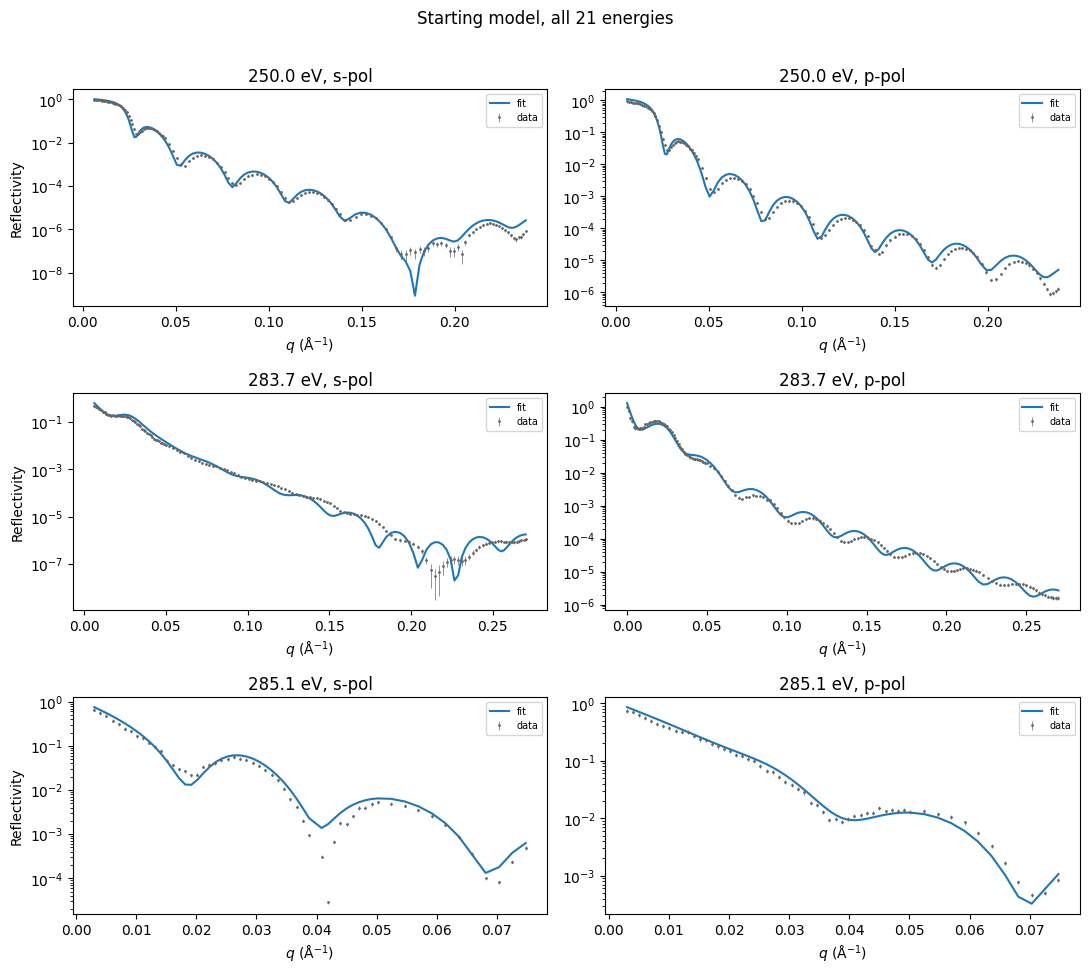

In [9]:
def plot_data_vs_model(model, title, show_energies=SHOW_ENERGIES):
    fig, axes = plt.subplots(
        len(show_energies), 2, figsize=(11, 3.2 * len(show_energies))
    )
    for row, energy in enumerate(show_energies):
        for col, pol in enumerate(("s", "p")):
            ax = axes[row, col]
            for e, p, indices in dataset.groups():
                if e != energy or p != pol:
                    continue
                q = dataset.q[indices]
                ax.errorbar(
                    q,
                    dataset.r[indices],
                    yerr=dataset.r_err[indices],
                    fmt=".",
                    ms=2,
                    lw=0.5,
                    color="0.4",
                    label="data",
                )
                pred = model(q, energy)
                ax.plot(
                    q, pred.s if pol == "s" else pred.p, color="C0", lw=1.5, label="fit"
                )
            ax.set_yscale("log")
            ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
            ax.set_title(f"{energy:.1f} eV, {pol}-pol")
            if col == 0:
                ax.set_ylabel("Reflectivity")
            ax.legend(fontsize="x-small")
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_data_vs_model(model, "Starting model, all 21 energies")


## Fit 1: shared geometry + densities against all 21 energies


3266.8221930033183: : 50it [04:21,  5.24s/it]


logl after fit 1: -3266.822


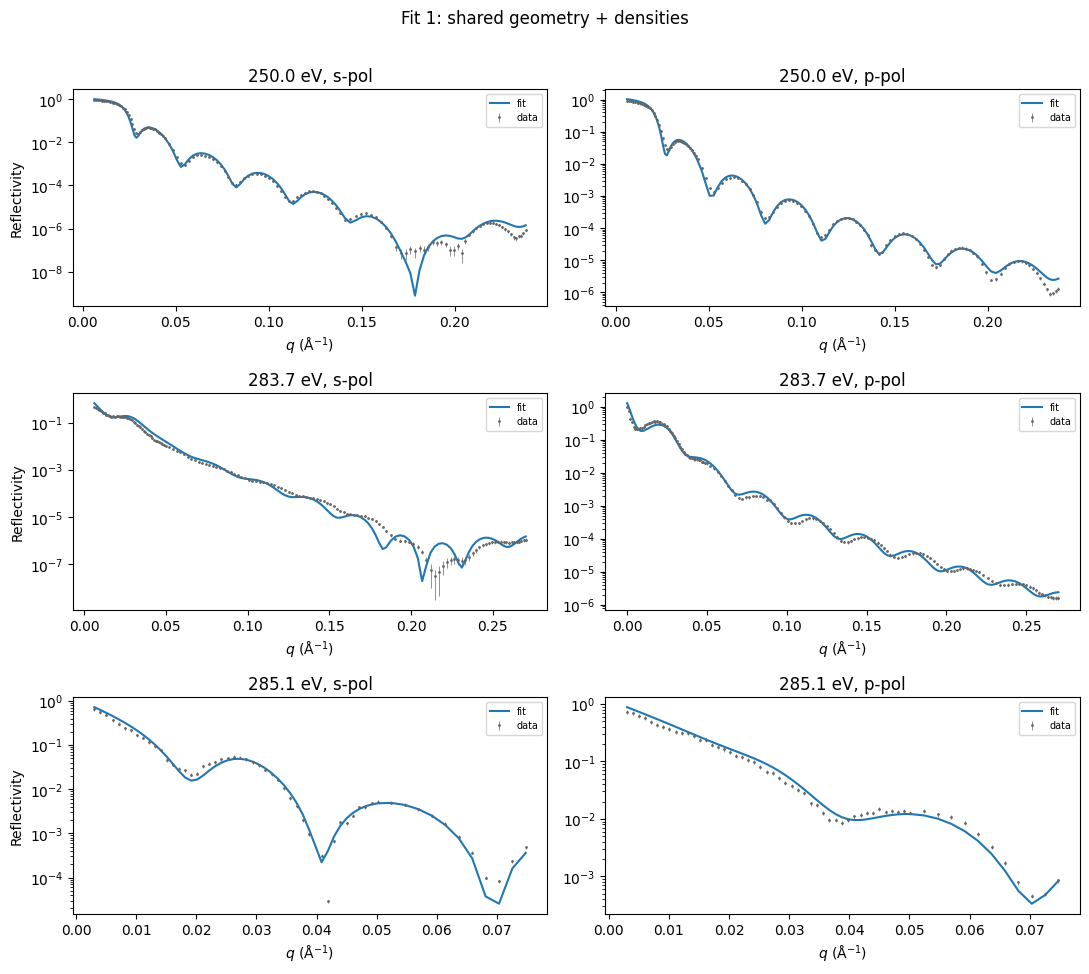

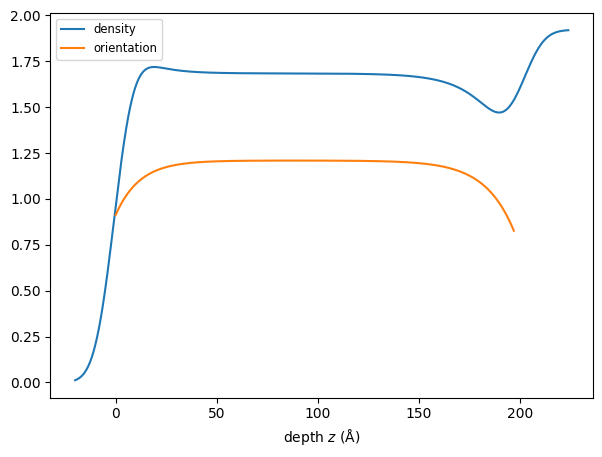

In [10]:
x0 = [p.value for p in objective.varying_parameters()]
with thread_workers(12) as workers:
    workers.bind(objective)
    CurveFitter(objective).fit(
        method="differential_evolution",
        workers=workers,
        updating="deferred",
        maxiter=50,
        popsize=10,
        polish=False,
        x0=x0,
    )
print(f"logl after fit 1: {objective.logl():.3f}")
plot_data_vs_model(model, "Fit 1: shared geometry + densities")
structure_fit.plot.param("density|orientation", roughness=True)
plt.show()


## Fit 2: open substrate-/vacuum-side tilt and relaxation lengths


In [11]:
profile_fit.tau_si.setp(vary=True, bounds=(0.5, 25.0))
profile_fit.tau_vac.setp(vary=True, bounds=(0.5, 25.0))
profile_fit.alpha_si.setp(vary=True, bounds=(0.0, np.pi / 4))
profile_fit.alpha_vac.setp(vary=True, bounds=(0.0, np.pi / 2))

with thread_workers(12) as workers:
    workers.bind(objective)
    CurveFitter(objective).fit(
        method="differential_evolution",
        workers=workers,
        updating="deferred",
        maxiter=50,
        popsize=10,
        polish=False,
    )
print(f"logl after fit 2: {objective.logl():.3f}")
plot_data_vs_model(model, "Fit 2: + alpha_si, alpha_vac")
structure_fit.plot.param("density|orientation", roughness=True)
plt.show()


16221.188530185942: : 1it [00:13, 13.49s/it]


KeyboardInterrupt: 

## Fit 3: final polish (same free parameters as fit 2)


21288.728341050926: : 30it [51:29, 102.97s/it]


logl after fit 3: -21288.728
varying parameters:
________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@250p0eV', value=0.856972          , bounds=[0.5, 2.1]>
<Parameter:'scale_p@250p0eV', value=1.1667          , bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s@250p0eV', value=-0.0101177          , bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p@250p0eV', value=0.464443          , bounds=[-1.5, 1.5]>
<Parameter:'scale_s@275p0eV', value=1.46776          , bounds=[0.5, 2.1]>
<Parameter:'scale_p@275p0eV', value=1.66763          , bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s@275p0eV', value=0.440875          , bounds=[-1.5, 1.5]>
<Parameter:'theta_offset_p@275p0eV', value=0.317476          , bounds=[-1.5, 1.5]>
<Parameter:'scale_s@280p0eV', value=1.25247          , bounds=[0.5, 2.1]>
<Parameter:'scale_p@280p0eV', value=1.42953          , bounds=[0.5, 2.1]>
<Parameter:'theta_offset_s@280p0eV', value=-0.252419          , 

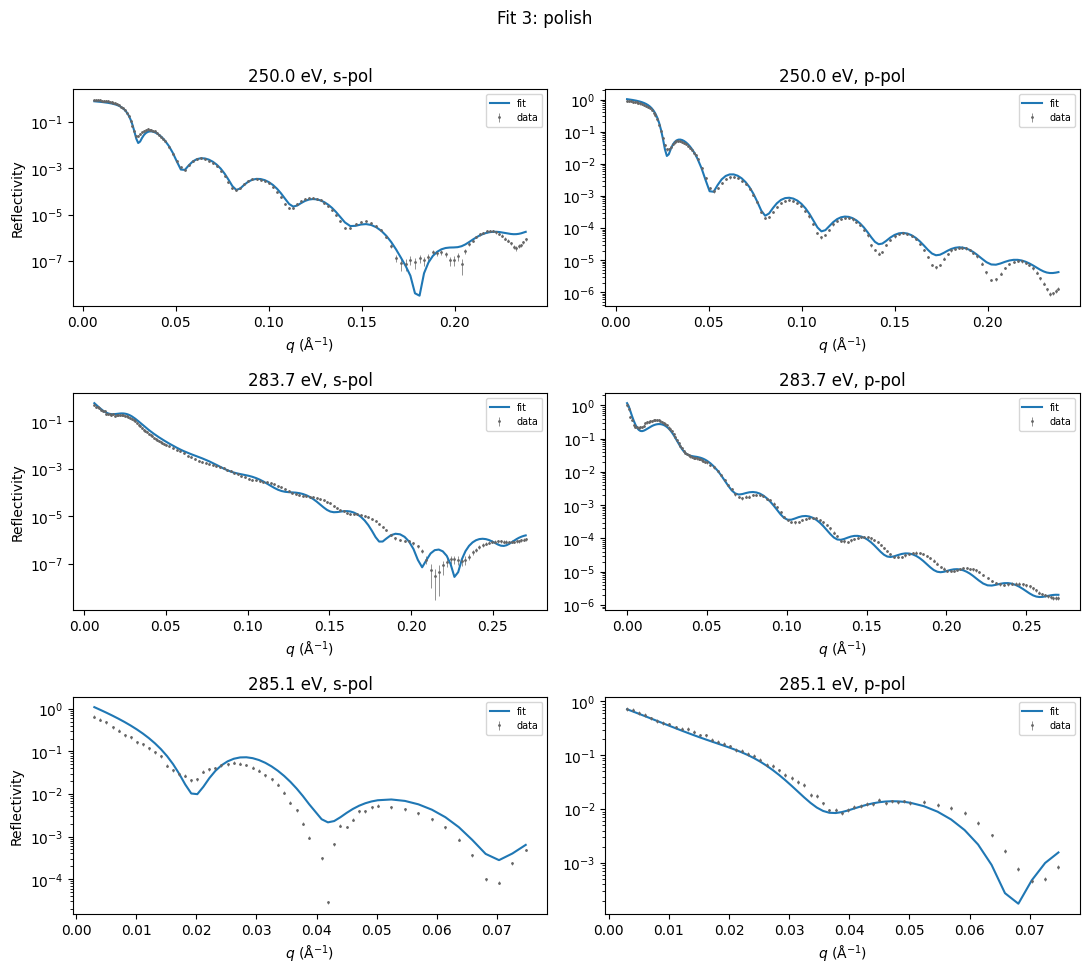

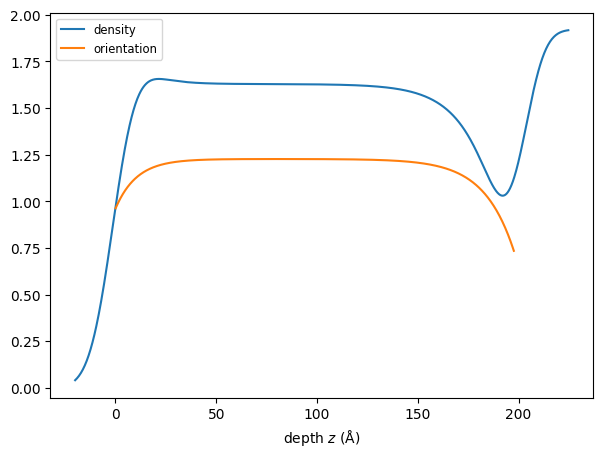

In [ ]:
x0 = [p.value for p in objective.varying_parameters()]
with thread_workers(12) as workers:
    workers.bind(objective)
    CurveFitter(objective).fit(
        method="differential_evolution",
        workers=workers,
        updating="deferred",
        maxiter=30,
        popsize=10,
        polish=True,
        x0=x0,
    )
print(f"logl after fit 3: {objective.logl():.3f}")
print(f"varying parameters:\n{objective.varying_parameters()}")
plot_data_vs_model(model, "Fit 3: polish")
structure_fit.plot.param("density|orientation", roughness=True)
plt.show()
assert np.isfinite(objective.logl())


## Reflectivity overlay: data vs our fit vs legacy DFT prediction


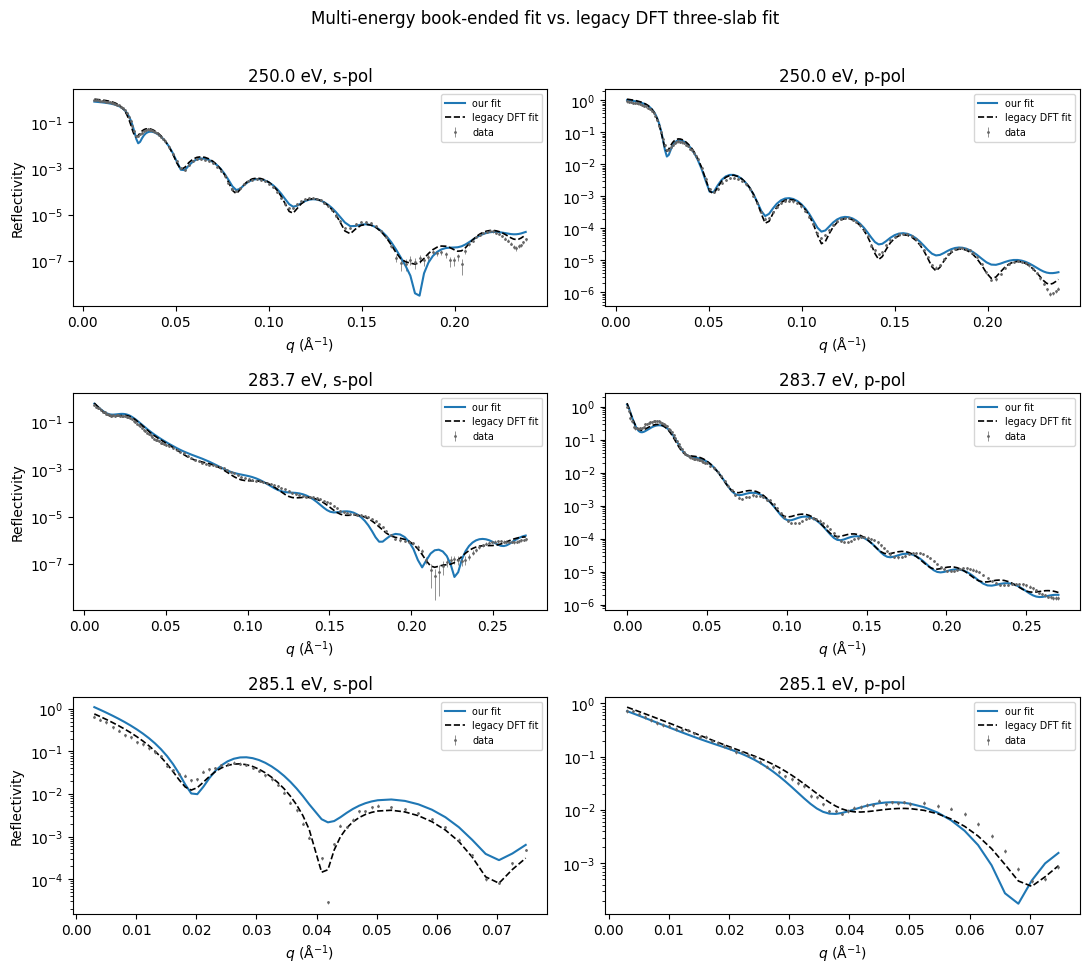

In [ ]:
fig, axes = plt.subplots(len(SHOW_ENERGIES), 2, figsize=(11, 3.2 * len(SHOW_ENERGIES)))
for row, energy in enumerate(SHOW_ENERGIES):
    legacy_group = frame.filter(pl.col("energy") == energy)
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        for e, p, indices in dataset.groups():
            if e != energy or p != pol:
                continue
            q = dataset.q[indices]
            ax.errorbar(
                q,
                dataset.r[indices],
                yerr=dataset.r_err[indices],
                fmt=".",
                ms=2,
                lw=0.5,
                color="0.4",
                label="data",
            )
            pred = model(q, energy)
            ax.plot(
                q,
                pred.s if pol == "s" else pred.p,
                color="C0",
                lw=1.5,
                label="our fit",
            )
        legacy_sub = legacy_group.filter(pl.col("pol") == pol)
        if not legacy_sub.is_empty():
            order = np.argsort(legacy_sub["q"].to_numpy())
            ax.plot(
                legacy_sub["q"].to_numpy()[order],
                legacy_sub["legacy_pred"].to_numpy()[order],
                color="k",
                ls="--",
                lw=1.2,
                label="legacy DFT fit",
            )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle("Multi-energy book-ended fit vs. legacy DFT three-slab fit", y=1.01)
fig.tight_layout()
plt.show()


## Depth profile: fitted book-ended film vs DFT three-slab template


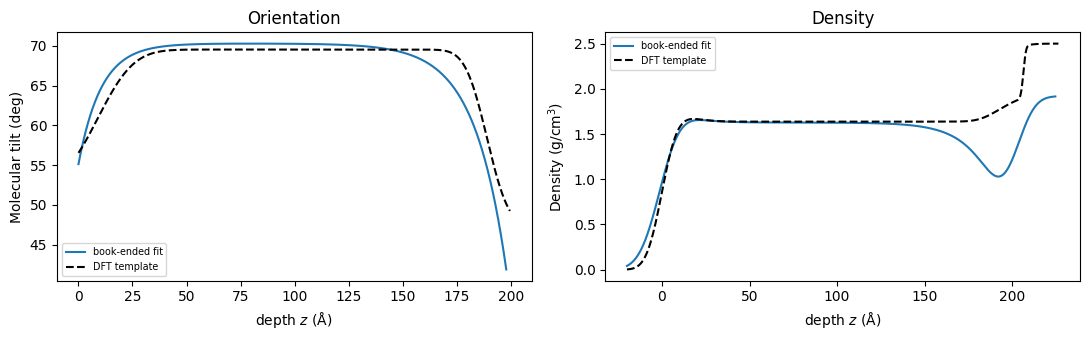

In [ ]:
z_fit = structure_fit.depth_grid(num_points=2000, pad=20.0)
z_template = template_structure.depth_grid(num_points=2000, pad=20.0)
_, density_fit = structure_fit.density_profile_at(z_fit, roughness=True)
_, orientation_fit = structure_fit.orientation_profile_at(z_fit, roughness=True)
_, density_template = template_structure.density_profile_at(z_template, roughness=True)
_, orientation_template = template_structure.orientation_profile_at(
    z_template, roughness=True
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(z_fit, np.rad2deg(orientation_fit), color="C0", label="book-ended fit")
axes[0].plot(
    z_template,
    np.rad2deg(orientation_template),
    color="k",
    ls="--",
    label="DFT template",
)
axes[0].set_title("Orientation")
axes[0].set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
axes[0].set_ylabel("Molecular tilt (deg)")
axes[0].legend(fontsize="x-small")

axes[1].plot(z_fit, density_fit, color="C0", label="book-ended fit")
axes[1].plot(z_template, density_template, color="k", ls="--", label="DFT template")
axes[1].set_title("Density")
axes[1].set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
axes[1].set_ylabel(r"Density (g/cm$^3$)")
axes[1].legend(fontsize="x-small")
fig.tight_layout()
plt.show()


## Save the fitted objective

Refloxide-native pickle; no pyref / refnx-legacy dependency required to reload.


In [ ]:
FIT_OUT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/refloxide"
FIT_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_OUT_PATH = FIT_OUT_DIR / "graded_orientation_multi_energy_refit-refloxide.pkl"
with FIT_OUT_PATH.open("wb") as f:
    pickle.dump(objective, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"saved fitted objective to {FIT_OUT_PATH}")
